In [9]:
import numpy as np
import pandas as pd
import joblib
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import Ridge
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Define the class exactly as it was saved
class MarketingModel:
    def __init__(self, alpha=1.0, n_splits=5):
        self.alpha = alpha
        self.n_splits = n_splits
        self.model = Ridge(alpha=self.alpha)
        self.cv_results = None
        self.feature_cols = None
        self.target_col = None
        self.preprocessor = None
    
    def get_coefficients(self):
        coef_df = pd.DataFrame({
            'Feature': self.feature_cols,
            'Coefficient': self.model.coef_
        }).sort_values('Coefficient', ascending=False)
        return coef_df

print("MarketingModel class defined")
# Load model and preprocessor from Module 2
model = joblib.load('marketing_model_pro.pkl')
preprocessor = joblib.load('preprocessor.pkl')

# Load data for reference
df = pd.read_csv('data_processed_module1.csv')

print("Model and preprocessor loaded")
print(f"Features used: {model.feature_cols}")
print(f"Model intercept: {model.model.intercept_:.2f}")

MarketingModel class defined
Model and preprocessor loaded
Features used: ['FB_Spend', 'GG_Spend', 'Promo', 'Seasonality']
Model intercept: 399.51


In [10]:
class BudgetOptimizer:
    
    def __init__(self, model, preprocessor, promo_value=0, season_value=1):
        self.model = model
        self.preprocessor = preprocessor
        self.promo = promo_value
        self.season = season_value
        
        # Get coefficients from model
        coef_df = model.get_coefficients()
        self.coef_dict = dict(zip(coef_df['Feature'], coef_df['Coefficient']))
        self.intercept = model.model.intercept_
        
        print(f"\nCoefficients loaded:")
        print(f"   FB_Spend: {self.coef_dict.get('FB_Spend', 0):.4f}")
        print(f"   GG_Spend: {self.coef_dict.get('GG_Spend', 0):.4f}")
        print(f"   Promo: {self.coef_dict.get('Promo', 0):.2f}")
        print(f"   Seasonality: {self.coef_dict.get('Seasonality', 0):.2f}")
        print(f"   Intercept: {self.intercept:.2f}")
    
    def sales_function(self, spends):
        """
        Calculate sales based on spend
        spends = [FB_spend, GG_spend]
        """
        fb_spend, gg_spend = spends
        
        # Create dataframe with correct columns
        input_df = pd.DataFrame({
            'FB_Spend': [fb_spend],
            'GG_Spend': [gg_spend],
            'Promo': [self.promo],
            'Seasonality': [self.season]
        })
        
        # Scale features (important!)
        X_scaled = self.preprocessor.transform(input_df)
        
        # Predict
        sales = self.model.model.predict(X_scaled)[0]
        
        return sales
    
    def objective(self, spends):
        """Objective: maximize sales -> minimize negative sales"""
        return -self.sales_function(spends)
    
    def optimize(self, budget_total, min_spend=0, max_spend=None):
        """
        Optimize budget allocation
        
        Parameters:
        -----------
        budget_total : float
            Total budget
        min_spend : float or list
            Minimum spend per channel
        max_spend : float or list
            Maximum spend per channel
        """
        n_channels = 2  # FB and GG
        
        # Initial guess: equal split
        initial_spends = [budget_total / n_channels, budget_total / n_channels]
        
        # Constraint: total spend = budget_total
        constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - budget_total}]
        
        # Bounds for each channel
        if max_spend is None:
            max_spend = budget_total
        
        if isinstance(min_spend, (int, float)):
            min_spend = [min_spend, min_spend]
        if isinstance(max_spend, (int, float)):
            max_spend = [max_spend, max_spend]
        
        bounds = [(min_spend[i], max_spend[i]) for i in range(n_channels)]
        
        # Run optimization
        result = minimize(self.objective, initial_spends, 
                         method='SLSQP', 
                         bounds=bounds, 
                         constraints=constraints)
        
        if result.success:
            optimal_spends = result.x
            optimal_sales = -result.fun
            return optimal_spends, optimal_sales
        else:
            print(f"Optimization warning: {result.message}")
            return initial_spends, self.sales_function(initial_spends)
    
    def compare_with_equal_split(self, budget_total):
        """Compare optimal allocation vs equal split"""
        # Optimal allocation
        optimal, sales_opt = self.optimize(budget_total, min_spend=500, max_spend=budget_total*0.8)
        
        # Equal split
        equal = [budget_total/2, budget_total/2]
        sales_equal = self.sales_function(equal)
        
        # Calculate improvement
        improvement = (sales_opt - sales_equal) / sales_equal * 100
        
        print("\n" + "="*60)
        print(f"BUDGET OPTIMIZATION COMPARISON (Budget: {budget_total:,.0f})")
        print("="*60)
        print(f"{'Method':<15} {'FB':>12} {'GG':>12} {'Sales':>12}")
        print("-"*60)
        print(f"{'Equal split':<15} {equal[0]:>12,.0f} {equal[1]:>12,.0f} {sales_equal:>12,.0f}")
        print(f"{'Optimal':<15} {optimal[0]:>12,.0f} {optimal[1]:>12,.0f} {sales_opt:>12,.0f}")
        print("-"*60)
        print(f"\nImprovement: +{improvement:.1f}%")
        
        return optimal, sales_opt, improvement

print("BudgetOptimizer class defined")

BudgetOptimizer class defined


In [11]:
# Initialize optimizer (no promo, average seasonality)
optimizer = BudgetOptimizer(model, preprocessor, promo_value=0, season_value=df['Seasonality'].mean())

# Test different budget levels
budgets = [5000, 10000, 15000, 20000, 30000]
results = []

print("\n" + "="*60)
print("OPTIMIZATION ACROSS DIFFERENT BUDGETS")
print("="*60)

for budget in budgets:
    try:
        optimal, sales = optimizer.optimize(budget, min_spend=500, max_spend=budget*0.8)
        results.append({
            'Budget': budget,
            'FB_Spend': optimal[0],
            'GG_Spend': optimal[1],
            'Expected_Sales': sales,
            'ROI': sales / budget * 1000
        })
        print(f"Budget {budget:,.0f}: FB={optimal[0]:,.0f}, GG={optimal[1]:,.0f} -> Sales={sales:.0f}")
    except Exception as e:
        print(f"Budget {budget}: Error - {e}")

df_results = pd.DataFrame(results)
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(df_results.round(0))


Coefficients loaded:
   FB_Spend: 5.1695
   GG_Spend: 17.1346
   Promo: 13.74
   Seasonality: 42.51
   Intercept: 399.51

OPTIMIZATION ACROSS DIFFERENT BUDGETS
Budget 5,000: FB=1,000, GG=4,000 -> Sales=369
Budget 10,000: FB=2,000, GG=8,000 -> Sales=406
Budget 15,000: FB=3,000, GG=12,000 -> Sales=443
Budget 20,000: FB=4,000, GG=16,000 -> Sales=480
Budget 30,000: FB=6,000, GG=24,000 -> Sales=553

SUMMARY TABLE
   Budget  FB_Spend  GG_Spend  Expected_Sales   ROI
0    5000    1000.0    4000.0           369.0  74.0
1   10000    2000.0    8000.0           406.0  41.0
2   15000    3000.0   12000.0           443.0  30.0
3   20000    4000.0   16000.0           480.0  24.0
4   30000    6000.0   24000.0           553.0  18.0


In [12]:
# Default budget
default_budget = 10000

# No promo
opt_no_promo = BudgetOptimizer(model, preprocessor, promo_value=0, season_value=df['Seasonality'].mean())
fb_no, gg_no = opt_no_promo.optimize(default_budget, min_spend=500, max_spend=default_budget*0.8)[0]
sales_no = opt_no_promo.optimize(default_budget, min_spend=500, max_spend=default_budget*0.8)[1]

# With promo
opt_with_promo = BudgetOptimizer(model, preprocessor, promo_value=1, season_value=df['Seasonality'].mean())
fb_with, gg_with = opt_with_promo.optimize(default_budget, min_spend=500, max_spend=default_budget*0.8)[0]
sales_with = opt_with_promo.optimize(default_budget, min_spend=500, max_spend=default_budget*0.8)[1]

print("\n" + "="*60)
print(f"PROMO COMPARISON (Budget: {default_budget:,.0f})")
print("="*60)
print(f"Without Promo: FB={fb_no:.0f}, GG={gg_no:.0f} -> Sales={sales_no:.0f}")
print(f"With Promo:    FB={fb_with:.0f}, GG={gg_with:.0f} -> Sales={sales_with:.0f}")
print(f"\nLift from Promo: +{sales_with - sales_no:.0f} sales (+{(sales_with/sales_no - 1)*100:.1f}%)")


Coefficients loaded:
   FB_Spend: 5.1695
   GG_Spend: 17.1346
   Promo: 13.74
   Seasonality: 42.51
   Intercept: 399.51

Coefficients loaded:
   FB_Spend: 5.1695
   GG_Spend: 17.1346
   Promo: 13.74
   Seasonality: 42.51
   Intercept: 399.51

PROMO COMPARISON (Budget: 10,000)
Without Promo: FB=2000, GG=8000 -> Sales=406
With Promo:    FB=2000, GG=8000 -> Sales=449

Lift from Promo: +43 sales (+10.5%)


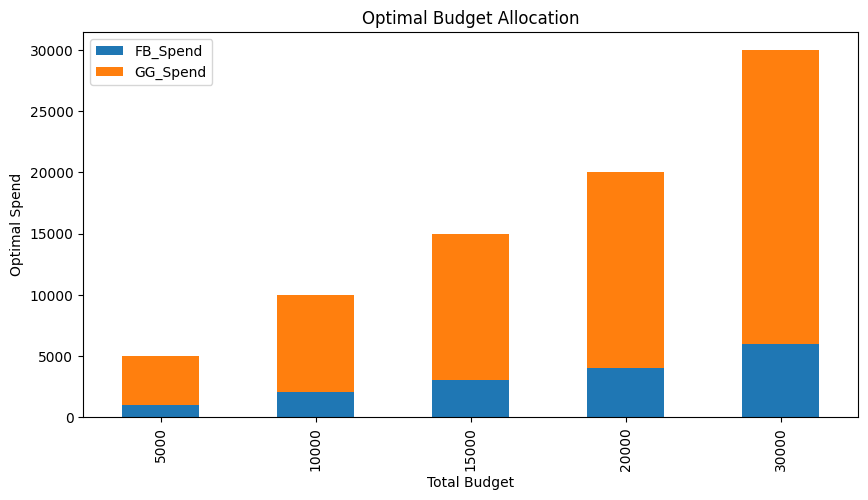

In [13]:
# Pandas built-in plot
df_results.set_index('Budget')[['FB_Spend', 'GG_Spend']].plot(kind='bar', stacked=True, figsize=(10, 5))
plt.xlabel('Total Budget')
plt.ylabel('Optimal Spend')
plt.title('Optimal Budget Allocation')
plt.show()

In [14]:
# Save optimization results
df_results.to_csv('optimization_results.csv', index=False)
print("Saved optimization results to 'optimization_results.csv'")

print("\n" + "="*60)
print("MODULE 3 - COMPLETED")
print("="*60)
print("Key insights:")
print(f"   - GG is more effective than FB (coefficient {optimizer.coef_dict.get('GG_Spend', 0):.2f} vs {optimizer.coef_dict.get('FB_Spend', 0):.2f})")
print(f"   - With budget {default_budget:,.0f}: FB={fb_no:.0f}, GG={gg_no:.0f}")
print(f"   - Expected sales: {sales_no:.0f}")
print(f"   - Promo lift: +{sales_with - sales_no:.0f} sales (+{(sales_with/sales_no - 1)*100:.1f}%)")

Saved optimization results to 'optimization_results.csv'

MODULE 3 - COMPLETED
Key insights:
   - GG is more effective than FB (coefficient 17.13 vs 5.17)
   - With budget 10,000: FB=2000, GG=8000
   - Expected sales: 406
   - Promo lift: +43 sales (+10.5%)
